In [46]:
!pip install numpy


In [1]:
import pandas as pd
import numpy as np

In [2]:
data=pd.read_csv("powerplant_data.csv")

In [3]:
data.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [4]:
data.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [5]:
X=data.drop("PE",axis=1)
y=data["PE"]

In [6]:
X.head()

,AT,V,AP,RH
0,8.34,40.77,1010.84,90.01
1,23.64,58.49,1011.40,74.20
2,29.74,56.90,1007.15,41.91
3,19.07,49.69,1007.22,76.79
4,11.80,40.66,1017.13,97.20


In [7]:
y.head()

0    480.48
1    445.75
2    438.76
3    453.09
4    464.43
Name: PE, dtype: float64

In [8]:
!pip install scikit-learn
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [9]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
X_train_scaled=sc.fit_transform(X_train)
X_test_scaled=sc.transform(X_test)

In [10]:
import torch
import torch.nn as nn

In [31]:
X_train_tensor=torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor=torch.tensor(y_train.values, dtype=torch.float32).view(-1,1)
X_test_tensor=torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor=torch.tensor(y_test.values, dtype=torch.float32).view(-1,1)


In [32]:
from torch.utils.data import TensorDataset,DataLoader

train_dataset=TensorDataset(X_train_tensor,y_train_tensor)
test_dataset=TensorDataset(X_test_tensor,y_test_tensor)


In [33]:
train_Loader=DataLoader(train_dataset,batch_size=32,shuffle=True)
test_Loader=DataLoader(test_dataset,batch_size=32)


In [34]:
#Define architecture of the model

class Ann(nn.Module):
    def __init__(self):
        super(Ann,self).__init__()

        self.model=nn.Sequential(
            #1st input layer
            nn.Linear(X_train.shape[1],6),
            nn.ReLU(),

            #Hidden layer
            nn.Linear(6,6),
            nn.ReLU(),

            #Output layer
            nn.Linear(6,1),
        )

    def forward(self,x):
        return self.model(x)

In [35]:
import torch.optim as optim

model=Ann()

#Loss and optimizer
criterian=nn.MSELoss()
optimizer=optim.Adam(model.parameters())

In [40]:
#Train the ANN
epoches=100
train_loses=[]
val_loses=[]

best_loss_val=float("inf")

for epoch in range(epoches):
    model.train()
    running_loss=0.0

    for xb,yb in train_Loader:
        optimizer.zero_grad()
        
        outputs=model(xb)
        loss=criterian(outputs,yb)
        loss.backward()
        optimizer.step()

        running_loss+=loss.item()

    epoch_train_loss=running_loss/len(train_Loader)
    train_loses.append(epoch_train_loss)

    #Validation
    model.eval()
    running_val_loss=0.0

    with torch.no_grad():
        for xb,yb in test_Loader:
            outputs=model(xb)
            loss=criterian(outputs,yb)
            #Here no backward propagation
            running_val_loss+=loss.item()

    epoch_test_loss=running_val_loss/len(test_Loader)
    val_loses.append(epoch_test_loss)

    print("epoche = ", epoch+1 ,"/",epoches,"=====> epoch traianing losss=",epoch_train_loss,"==> epoch Validadtion losss=",epoch_test_loss)

    if epoch_test_loss<best_loss_val:
        best_loss_val=epoch_test_loss
        torch.save(model.state_dict(),"best_model.pt")

epoche =  1 / 100 =====> epoch traianing losss= 19.5539408326149 ==> epoch Validadtion losss= 18.07616242567698
epoche =  2 / 100 =====> epoch traianing losss= 19.46282380024592 ==> epoch Validadtion losss= 18.657624411582947
epoche =  3 / 100 =====> epoch traianing losss= 19.59612121184667 ==> epoch Validadtion losss= 19.168550753593443
epoche =  4 / 100 =====> epoch traianing losss= 19.41959774096807 ==> epoch Validadtion losss= 18.309633501370747
epoche =  5 / 100 =====> epoch traianing losss= 19.437895317872364 ==> epoch Validadtion losss= 18.243028783798216
epoche =  6 / 100 =====> epoch traianing losss= 19.36798867583275 ==> epoch Validadtion losss= 17.85666104952494
epoche =  7 / 100 =====> epoch traianing losss= 19.402638630072275 ==> epoch Validadtion losss= 18.11338127454122
epoche =  8 / 100 =====> epoch traianing losss= 19.236031913757323 ==> epoch Validadtion losss= 17.951031533877053
epoche =  9 / 100 =====> epoch traianing losss= 19.337326673666634 ==> epoch Validadtion 

Text(0, 0.5, 'losses')

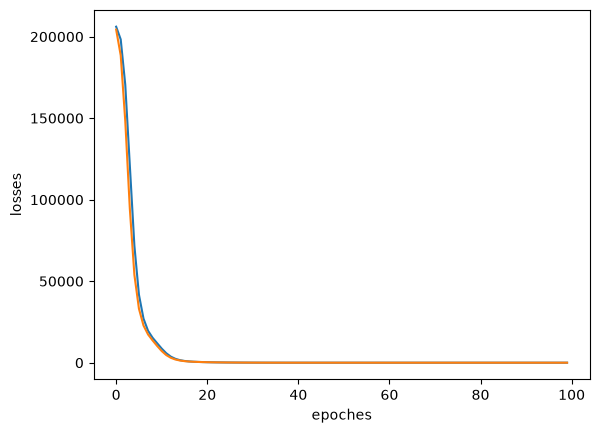

In [39]:
import matplotlib.pyplot as plt

loss_data=pd.DataFrame({"training loss":train_loses,
                       "Validation loss":val_loses})

plt.plot(loss_data["training loss"], label="Training loss")
plt.plot(loss_data["Validation loss"], label="Validation loss")

plt.xlabel("epoches")
plt.ylabel("losses")

In [41]:
#Loading the best model
model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

In [42]:
#Evaluate our model

model.eval()

with torch.no_grad():
    train_pred=model(X_train_tensor)
    test_pred=model(X_test_tensor)

    train_mse=criterian(train_pred,y_train_tensor)
    test_mse=criterian(test_pred,y_test_tensor)

    print("Training MSE:",train_mse.item())
    print("Testing MSE:",test_mse.item())

Training MSE: 18.577003479003906
Testing MSE: 17.078330993652344


In [47]:
from sklearn.metrics import r2_score

print(r2_score(test_pred,y_test_tensor))

0.9366602897644043


In [48]:
Predicted_values=pd.DataFrame(test_pred.numpy(),columns=["Predicted_values"])
Actual_values=pd.DataFrame(y_test_tensor.numpy(),columns=["Actual_values"])

pd.concat([Predicted_values,Actual_values],axis=1)

,Predicted_values,Actual_values
0,436.274780,433.269989
1,436.959137,438.160004
2,461.010834,458.420013
3,476.483246,480.820007
4,438.263153,441.410004
...,...,...
1909,449.624359,456.700012
1910,433.050537,438.040009
1911,467.467926,467.799988
1912,432.467224,437.140015
